# PCA through Singular Value Decomposition

In [3]:
import numpy as np

# Defined 3 points in 2D-space:
X = np.array([[2, 1, 0],
              [4, 3, 0]], dtype=float)

# Calculate the covariance matrix:
R = np.cov(X)

# Calculate the SVD decomposition and new basis vectors:
[U, D, V] = np.linalg.svd(R)  # call SVD decomposition
u1 = U[:, 0]  # first principal direction
u2 = U[:, 1]  # second principal direction

# Calculate the coordinates in new orthonormal basis:
X_mean = np.mean(X, axis=1, keepdims=True)
Xc = X - X_mean
Z = U.T @ Xc   # coordinates in the new basis

# Calculate the approximation of the original from new basis
X_reconstructed = U @ Z + X_mean

# Check that you got the original
print(np.allclose(X, X_reconstructed))
print(X_reconstructed)

True
[[ 2.00000000e+00  1.00000000e+00  3.33066907e-16]
 [ 4.00000000e+00  3.00000000e+00 -4.44089210e-16]]


# PCA on Iris data

In [4]:
# Load Iris dataset as in the last PC lab:
from sklearn.datasets import load_iris
iris=load_iris()
iris.feature_names
print(iris.feature_names)
print(iris.data[0:5,:])
print(iris.target[:])

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


<function matplotlib.pyplot.show(close=None, block=None)>

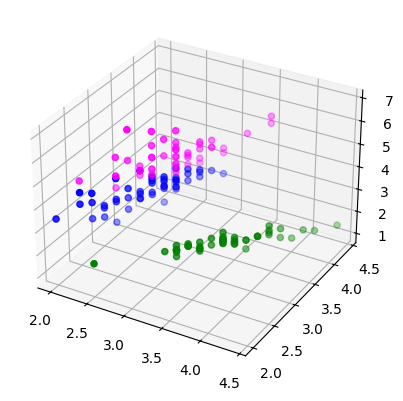

In [7]:
# We have 4 dimensions of data, plot the first three colums in 3D
X=iris.data
y=iris.target
import matplotlib.pyplot as plt
axes1=plt.axes(projection='3d')
axes1.scatter3D(X[y==0,1],X[y==0,1],X[y==0,2],color='green')
axes1.scatter3D(X[y==1,1],X[y==1,1],X[y==1,2],color='blue')
axes1.scatter3D(X[y==2,1],X[y==2,1],X[y==2,2],color='magenta')
plt.show


Covariance matrix of PCA model:
[[ 1.00671141 -0.11835884  0.87760447  0.82343066]
 [-0.11835884  1.00671141 -0.43131554 -0.36858315]
 [ 0.87760447 -0.43131554  1.00671141  0.96932762]
 [ 0.82343066 -0.36858315  0.96932762  1.00671141]]


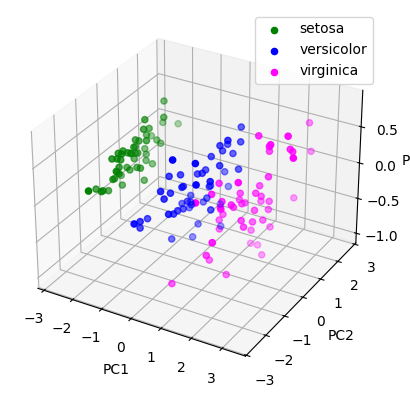

In [12]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Standardization (zero mean, unit variance)
scaler = StandardScaler()
Xpp = scaler.fit_transform(X)

# PCA with 3 components
pca = PCA(n_components=3)
Xpca = pca.fit_transform(Xpp)

print("Covariance matrix of PCA model:")
print(pca.get_covariance())

# 3D plot of PCA space
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(Xpca[y==0,0], Xpca[y==0,1], Xpca[y==0,2], color='green', label='setosa')
ax.scatter(Xpca[y==1,0], Xpca[y==1,1], Xpca[y==1,2], color='blue', label='versicolor')
ax.scatter(Xpca[y==2,0], Xpca[y==2,1], Xpca[y==2,2], color='magenta', label='virginica')

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.legend()

plt.show()

In [13]:
# Compute pca.explained_variance_ and pca.explained_cariance_ratio_values
pca.explained_variance_

array([2.93808505, 0.9201649 , 0.14774182])

In [14]:
pca.explained_variance_ratio_

array([0.72962445, 0.22850762, 0.03668922])

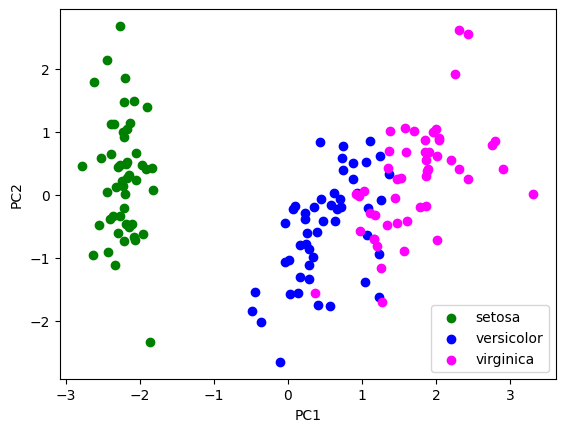

In [17]:
# Plot the principal components in 2D, mark different targets in color
import matplotlib.pyplot as plt

plt.scatter(Xpca[y==0,0], Xpca[y==0,1], color='green', label='setosa')
plt.scatter(Xpca[y==1,0], Xpca[y==1,1], color='blue', label='versicolor')
plt.scatter(Xpca[y==2,0], Xpca[y==2,1], color='magenta', label='virginica')

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.show()

# KNN classifier

Confusion matrix:
[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]


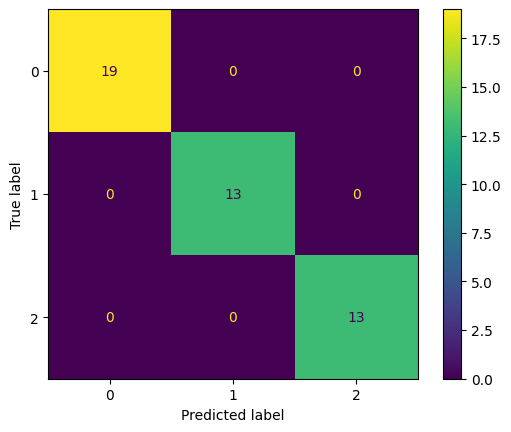

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Create and train KNN classifier (k=3)
knn1 = KNeighborsClassifier(n_neighbors=3)
knn1.fit(X_train, y_train)

# Predict on test set
Ypred = knn1.predict(X_test)

# Compute confusion matrix
cm = confusion_matrix(y_test, Ypred)
print("Confusion matrix:")
print(cm)

# Display confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, Ypred)
plt.show()

FULL 4D accuracy: 1.0
FULL 4D confusion matrix:
 [[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]


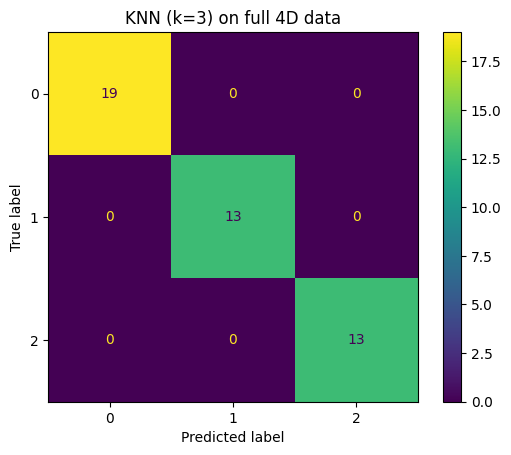

PCA (2D) accuracy: 0.9555555555555556
PCA (2D) confusion matrix:
 [[19  0  0]
 [ 0 11  2]
 [ 0  0 13]]


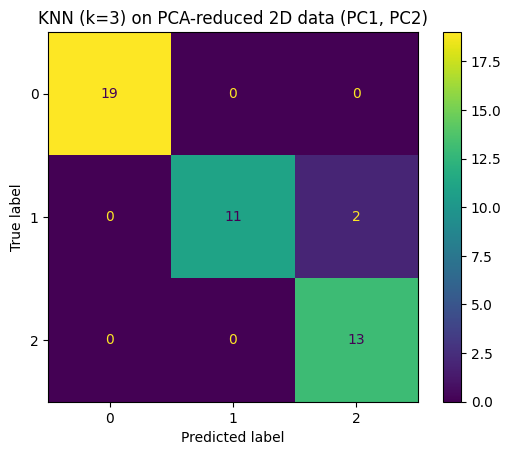

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt

# --- 1) KNN on FULL 4D dataset ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

knn_full = KNeighborsClassifier(n_neighbors=3)
knn_full.fit(X_train, y_train)
y_pred_full = knn_full.predict(X_test)

print("FULL 4D accuracy:", accuracy_score(y_test, y_pred_full))
print("FULL 4D confusion matrix:\n", confusion_matrix(y_test, y_pred_full))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_full)
plt.title("KNN (k=3) on full 4D data")
plt.show()


# --- 2) KNN on PCA data (first 2 principal components) ---
X2 = Xpca[:, :2]  # take only PC1 and PC2

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2, y, test_size=0.3, random_state=42
)

knn_pca = KNeighborsClassifier(n_neighbors=3)
knn_pca.fit(X_train2, y_train2)
y_pred_pca = knn_pca.predict(X_test2)

print("PCA (2D) accuracy:", accuracy_score(y_test2, y_pred_pca))
print("PCA (2D) confusion matrix:\n", confusion_matrix(y_test2, y_pred_pca))

ConfusionMatrixDisplay.from_predictions(y_test2, y_pred_pca)
plt.title("KNN (k=3) on PCA-reduced 2D data (PC1, PC2)")
plt.show()

Original 2D accuracy: 0.7555555555555555
Original 2D confusion matrix:
 [[19  0  0]
 [ 0  7  6]
 [ 0  5  8]]


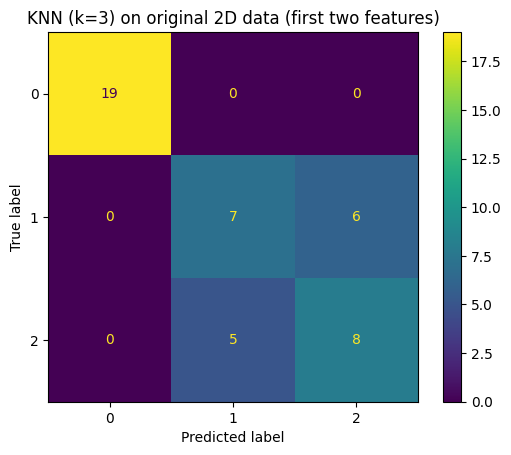

In [21]:
# Now do the same, but use only 2-dimensional data of original X (first two columns)
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt

# Use only first two original features
X2_original = X[:, :2]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X2_original, y, test_size=0.3, random_state=42
)

# Train KNN
knn_2d = KNeighborsClassifier(n_neighbors=3)
knn_2d.fit(X_train, y_train)

# Predict
y_pred = knn_2d.predict(X_test)

# Accuracy
print("Original 2D accuracy:", accuracy_score(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Original 2D confusion matrix:\n", cm)

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("KNN (k=3) on original 2D data (first two features)")
plt.show()